# HYPE Token DCF Valuation Model

An innovative Discounted Cash Flow analysis for Hyperliquid's HYPE token.

Check out the [Github](https://github.com/epistetechnician/hype-DCF)
Test it live here: https://epistetechnician.github.io/hype-DCF/

**Data Sources:**
- [ASXN Hyperliquid Dashboard](https://hyperscreener.asxn.xyz/home)
- [Hyperliquid Stats API](https://stats.hyperliquid.xyz/)
- [Token Terminal](https://tokenterminal.com/explorer/projects/hyperliquid)

---

In [3]:
# Install required packages
%pip install requests pandas numpy plotly ipywidgets scipy jupyter


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import requests
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import interact, interactive, fixed, widgets
from IPython.display import display, HTML, Markdown
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 1. Fetch Real-Time Hyperliquid Data

We'll pull data from the Hyperliquid API and stats endpoints.

In [5]:
class HyperliquidDataFetcher:
    """Fetch real-time data from Hyperliquid APIs."""
    
    def __init__(self):
        self.info_url = "https://api.hyperliquid.xyz/info"
        self.stats_url = "https://stats-data.hyperliquid.xyz"
        
    def get_meta(self):
        """Get market metadata."""
        try:
            response = requests.post(self.info_url, json={"type": "meta"})
            return response.json() if response.status_code == 200 else None
        except Exception as e:
            print(f"Error fetching meta: {e}")
            return None
    
    def get_all_mids(self):
        """Get all mid prices."""
        try:
            response = requests.post(self.info_url, json={"type": "allMids"})
            return response.json() if response.status_code == 200 else None
        except Exception as e:
            print(f"Error fetching mids: {e}")
            return None
    
    def get_spot_meta(self):
        """Get spot market metadata."""
        try:
            response = requests.post(self.info_url, json={"type": "spotMeta"})
            return response.json() if response.status_code == 200 else None
        except Exception as e:
            print(f"Error fetching spot meta: {e}")
            return None
    
    def get_clearinghouse_state(self):
        """Get clearinghouse state for volume/OI data."""
        try:
            response = requests.post(self.info_url, json={"type": "clearinghouseState", "user": "0x0000000000000000000000000000000000000000"})
            return response.json() if response.status_code == 200 else None
        except Exception as e:
            print(f"Error fetching clearinghouse state: {e}")
            return None
    
    def get_l2_snapshot(self, coin="HYPE"):
        """Get L2 order book snapshot."""
        try:
            response = requests.post(self.info_url, json={"type": "l2Book", "coin": coin})
            return response.json() if response.status_code == 200 else None
        except Exception as e:
            print(f"Error fetching L2 snapshot: {e}")
            return None

# Initialize fetcher
fetcher = HyperliquidDataFetcher()
print("✅ Data fetcher initialized")

✅ Data fetcher initialized


In [6]:
# Fetch current market data
print("Fetching Hyperliquid market data...")

meta = fetcher.get_meta()
all_mids = fetcher.get_all_mids()
spot_meta = fetcher.get_spot_meta()

# Get HYPE price from spot market
hype_price = float(all_mids.get('HYPE'))

print(f"\n📊 Current HYPE Price: ${hype_price:.2f}")

# Count active markets
if meta:
    perp_markets = len(meta.get('universe', []))
    print(f"📈 Active Perpetual Markets: {perp_markets}")

if spot_meta:
    spot_markets = len(spot_meta.get('tokens', []))
    print(f"💱 Active Spot Tokens: {spot_markets}")

Fetching Hyperliquid market data...

📊 Current HYPE Price: $25.82
📈 Active Perpetual Markets: 228
💱 Active Spot Tokens: 432


## 2. Core Metrics & Assumptions

Based on data from [ASXN Dashboard](https://hyperscreener.asxn.xyz/home) and public sources.

In [7]:
# Core metrics (sourced from ASXN Dashboard & public data)
# These can be updated with live API data when available

CORE_METRICS = {
    # Token Metrics
    'current_price': hype_price,
    'total_supply': 961_000_000,
    'circulating_supply': 356_500_000,
    'float_percent': 0.371,
    'burned_percent': 0.0986,
    
    # Revenue Metrics (2025 actuals)
    'annual_revenue_2025': 845_600_000,
    'annualized_revenue': 661_000_000,
    'daily_revenue': 3_120_000,
    
    # Volume Metrics
    'daily_perp_volume': 3_570_000_000,
    'cumulative_perp_volume': 3_673_000_000_000,
    'open_interest': 8_439_000_000,
    
    # Market Position
    'tvl': 4_477_000_000,
    'dau': 41_280,
    'market_share_perps': 0.70,  # 70% of on-chain perps
    'market_share_derivatives': 0.80,  # 80% of decentralized derivatives
    
    # Revenue Distribution
    'hlp_share': 0.93,
    'buyback_share': 0.07,
}

# Display as DataFrame
metrics_df = pd.DataFrame([
    ('Current Price', f"${CORE_METRICS['current_price']:.2f}"),
    ('Market Cap', f"${CORE_METRICS['current_price'] * CORE_METRICS['circulating_supply'] / 1e9:.2f}B"),
    ('FDV', f"${CORE_METRICS['current_price'] * CORE_METRICS['total_supply'] / 1e9:.2f}B"),
    ('2025 Revenue', f"${CORE_METRICS['annual_revenue_2025'] / 1e6:.1f}M"),
    ('Daily Volume', f"${CORE_METRICS['daily_perp_volume'] / 1e9:.2f}B"),
    ('Open Interest', f"${CORE_METRICS['open_interest'] / 1e9:.2f}B"),
    ('TVL', f"${CORE_METRICS['tvl'] / 1e9:.2f}B"),
    ('DAU', f"{CORE_METRICS['dau']:,}"),
    ('Market Share (Perps)', f"{CORE_METRICS['market_share_perps']*100:.0f}%"),
    ('Buyback % of Revenue', f"{CORE_METRICS['buyback_share']*100:.0f}%"),
], columns=['Metric', 'Value'])

display(HTML("<h3>Core Metrics Summary</h3>"))
display(metrics_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

Metric,Value
Current Price,$25.82
Market Cap,$9.20B
FDV,$24.81B
2025 Revenue,$845.6M
Daily Volume,$3.57B
Open Interest,$8.44B
TVL,$4.48B
DAU,"41,280"
Market Share (Perps),70%
Buyback % of Revenue,7%


## 3. DCF Model Engine

The innovative aspects of this DCF:
1. **Buyback-Adjusted Cash Flow** - Models 7% revenue flowing to token buybacks
2. **Deflationary Premium** - Accounts for supply reduction from burns
3. **Fee Switch Optionality** - Values potential governance changes
4. **HyperEVM Ecosystem Multiple** - Platform value beyond trading

In [8]:
class HYPEDCFModel:
    """DCF Model for HYPE Token.
    
    Values HYPE as equity with claim on full protocol value.
    Protocol revenue treated as quasi-earnings given minimal opex.
    """
    
    # Hyperliquid has minimal operating costs - mostly validator rewards
    # Profit margin ~85-90% (trading fees net of infrastructure costs)
    PROFIT_MARGIN = 0.85
    
    def __init__(self, metrics: dict):
        self.metrics = metrics
        self.projection_years = 5
        
    def project_revenue(self, base_revenue: float, growth_rates: list) -> pd.DataFrame:
        """Project revenue with given growth rates."""
        years = list(range(2026, 2026 + len(growth_rates)))
        revenues = [base_revenue]
        
        for i, rate in enumerate(growth_rates[:-1]):
            revenues.append(revenues[-1] * (1 + rate))
        
        return pd.DataFrame({
            'Year': years,
            'Revenue': revenues,
            'Growth': growth_rates
        })
    
    def calculate_free_cash_flow(self, revenue_df: pd.DataFrame, profit_margin: float = None) -> pd.DataFrame:
        """Calculate FCF from revenue. Protocol has minimal opex."""
        revenue_df = revenue_df.copy()
        margin = profit_margin if profit_margin else self.PROFIT_MARGIN
        revenue_df['FCF'] = revenue_df['Revenue'] * margin
        revenue_df['Buyback_Flow'] = revenue_df['Revenue'] * 0.07  # For display
        return revenue_df
    
    def discount_cash_flows(self, cash_flows: list, discount_rate: float) -> list:
        """Discount future cash flows to present value."""
        return [cf / ((1 + discount_rate) ** (i + 1)) for i, cf in enumerate(cash_flows)]
    
    def calculate_terminal_value(self, final_fcf: float, terminal_growth: float, discount_rate: float) -> float:
        """Gordon Growth Model for terminal value."""
        return (final_fcf * (1 + terminal_growth)) / (discount_rate - terminal_growth)
    
    def calculate_deflationary_premium(self, base_value: float, annual_burn_rate: float, years: int) -> float:
        """Premium from supply reduction via burns/buybacks."""
        cumulative_factor = 1.0
        for _ in range(years):
            cumulative_factor *= (1 / (1 - annual_burn_rate))
        return base_value * (cumulative_factor - 1)
    
    def calculate_ecosystem_premium(self, base_value: float, ecosystem_multiplier: float = 1.15) -> float:
        """Premium for HyperEVM ecosystem potential beyond trading."""
        return base_value * (ecosystem_multiplier - 1)
    
    def run_dcf(
        self,
        base_revenue: float,
        growth_rates: list,
        discount_rate: float,
        terminal_growth: float,
        buyback_pct: float = 0.07,  # Kept for display purposes
        include_deflationary: bool = True,
        include_fee_switch: bool = True,  # Now ecosystem premium
        annual_burn_rate: float = 0.02,
        profit_margin: float = None
    ) -> dict:
        """Run DCF valuation on full protocol value."""
        
        # Project revenues and calculate FCF
        revenue_df = self.project_revenue(base_revenue, growth_rates)
        revenue_df = self.calculate_free_cash_flow(revenue_df, profit_margin)
        
        # Discount FCF (full protocol cash flows)
        fcf_flows = revenue_df['FCF'].tolist()
        discounted_flows = self.discount_cash_flows(fcf_flows, discount_rate)
        
        # Terminal value on full FCF
        terminal_value = self.calculate_terminal_value(
            fcf_flows[-1], terminal_growth, discount_rate
        )
        discounted_terminal = terminal_value / ((1 + discount_rate) ** len(growth_rates))
        
        # Base DCF = PV of FCF + PV of Terminal Value
        base_dcf_value = sum(discounted_flows) + discounted_terminal
        
        # Deflationary premium (supply reduction increases per-token value)
        deflationary_premium = 0
        if include_deflationary:
            deflationary_premium = self.calculate_deflationary_premium(
                base_dcf_value, annual_burn_rate, len(growth_rates)
            )
        
        # Ecosystem premium (HyperEVM, spot trading growth)
        ecosystem_premium = 0
        if include_fee_switch:
            ecosystem_premium = self.calculate_ecosystem_premium(base_dcf_value)
        
        # Total enterprise value
        total_value = base_dcf_value + deflationary_premium + ecosystem_premium
        
        # Per-token values
        circulating = self.metrics['circulating_supply']
        total_supply = self.metrics['total_supply']
        
        return {
            'revenue_projections': revenue_df,
            'discounted_buyback_flows': discounted_flows,  # Now FCF for display
            'sum_discounted_flows': sum(discounted_flows),
            'terminal_value': terminal_value,
            'discounted_terminal': discounted_terminal,
            'base_dcf_value': base_dcf_value,
            'deflationary_premium': deflationary_premium,
            'fee_switch_optionality': ecosystem_premium,  # Renamed internally
            'total_enterprise_value': total_value,
            'implied_market_cap': total_value,
            'implied_fdv': total_value * (total_supply / circulating),
            'implied_price_circulating': total_value / circulating,
            'implied_price_fdv': total_value / total_supply,
            'current_price': self.metrics['current_price'],
            'upside_circulating': (total_value / circulating) / self.metrics['current_price'] - 1,
        }

# Initialize model
dcf_model = HYPEDCFModel(CORE_METRICS)
print("DCF Model initialized.")

DCF Model initialized.


## 4. Interactive DCF Analysis

Adjust the parameters below to see how valuations change under different scenarios.

In [9]:
def run_interactive_dcf(
    base_revenue_m: float,
    y1_growth: float,
    y2_growth: float,
    y3_growth: float,
    y4_growth: float,
    y5_growth: float,
    discount_rate: float,
    terminal_growth: float,
    buyback_pct: float,
    include_deflationary: bool,
    include_fee_switch: bool,
    annual_burn_rate: float
):
    """
    Interactive DCF runner with widgets.
    """
    growth_rates = [y1_growth/100, y2_growth/100, y3_growth/100, y4_growth/100, y5_growth/100]
    
    results = dcf_model.run_dcf(
        base_revenue=base_revenue_m * 1e6,
        growth_rates=growth_rates,
        discount_rate=discount_rate/100,
        terminal_growth=terminal_growth/100,
        buyback_pct=buyback_pct/100,
        include_deflationary=include_deflationary,
        include_fee_switch=include_fee_switch,
        annual_burn_rate=annual_burn_rate/100
    )
    
    # Create visualization
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Revenue Projections ($M)',
            'Discounted Cash Flows ($M)',
            'Valuation Waterfall ($B)',
            'Price Comparison'
        ),
        specs=[[{"type": "bar"}, {"type": "bar"}],
               [{"type": "waterfall"}, {"type": "bar"}]]
    )
    
    rev_df = results['revenue_projections']
    
    # Revenue projection
    fig.add_trace(
        go.Bar(
            x=rev_df['Year'],
            y=rev_df['Revenue'] / 1e6,
            name='Revenue',
            marker_color='#00D4AA',
            text=[f"${v/1e6:.0f}M" for v in rev_df['Revenue']],
            textposition='outside'
        ),
        row=1, col=1
    )
    
    # Discounted flows
    fig.add_trace(
        go.Bar(
            x=rev_df['Year'],
            y=[f/1e6 for f in results['discounted_buyback_flows']],
            name='Discounted Buybacks',
            marker_color='#7B68EE',
            text=[f"${f/1e6:.1f}M" for f in results['discounted_buyback_flows']],
            textposition='outside'
        ),
        row=1, col=2
    )
    
    # Valuation waterfall
    waterfall_labels = ['Discounted Flows', 'Terminal Value', 'Deflationary Premium', 
                        'Fee Switch Option', 'Total Value']
    waterfall_values = [
        results['sum_discounted_flows'] / 1e9,
        results['discounted_terminal'] / 1e9,
        results['deflationary_premium'] / 1e9,
        results['fee_switch_optionality'] / 1e9,
        0  # Total (measure)
    ]
    
    fig.add_trace(
        go.Waterfall(
            x=waterfall_labels,
            y=waterfall_values,
            measure=['relative', 'relative', 'relative', 'relative', 'total'],
            connector={"line": {"color": "rgb(63, 63, 63)"}},
            increasing={"marker": {"color": "#00D4AA"}},
            totals={"marker": {"color": "#FFD700"}},
            text=[f"${v:.2f}B" for v in waterfall_values[:-1]] + [f"${results['total_enterprise_value']/1e9:.2f}B"],
            textposition='outside'
        ),
        row=2, col=1
    )
    
    # Price comparison
    prices = ['Current', 'DCF Implied', 'FDV Implied']
    price_values = [
        results['current_price'],
        results['implied_price_circulating'],
        results['implied_price_fdv']
    ]
    colors = ['#FF6B6B', '#00D4AA', '#7B68EE']
    
    fig.add_trace(
        go.Bar(
            x=prices,
            y=price_values,
            marker_color=colors,
            text=[f"${p:.2f}" for p in price_values],
            textposition='outside'
        ),
        row=2, col=2
    )
    
    fig.update_layout(
        height=1000,
        showlegend=False,
        title_text="HYPE Token DCF Valuation Analysis",
        title_font_size=20,
        template='plotly_dark'
    )
    
    fig.show()
    
    # Summary output
    upside_pct = results['upside_circulating'] * 100
    upside_color = 'green' if upside_pct > 0 else 'red'
    
    summary_html = f"""
    <div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); 
                padding: 20px; border-radius: 10px; margin-top: 25px;">
        <h3 style="color: #00D4AA; margin-bottom: 15px;">DCF Valuation Summary</h3>
        <table style="width: 100%; color: white;">
            <tr>
                <td><b>Total Enterprise Value:</b></td>
                <td style="text-align: right; color: #FFD700;"><b>${results['total_enterprise_value']/1e9:.2f}B</b></td>
            </tr>
            <tr>
                <td>└ Base DCF (Buybacks):</td>
                <td style="text-align: right;">${results['base_dcf_value']/1e9:.2f}B</td>
            </tr>
            <tr>
                <td>└ Deflationary Premium:</td>
                <td style="text-align: right;">${results['deflationary_premium']/1e9:.2f}B</td>
            </tr>
            <tr>
                <td>└ Fee Switch Optionality:</td>
                <td style="text-align: right;">${results['fee_switch_optionality']/1e9:.2f}B</td>
            </tr>
            <tr style="border-top: 1px solid #444;">
                <td><b>Implied FDV:</b></td>
                <td style="text-align: right;"><b>${results['implied_fdv']/1e9:.2f}B</b></td>
            </tr>
            <tr>
                <td><b>Implied Price (Circ.):</b></td>
                <td style="text-align: right; color: #00D4AA;"><b>${results['implied_price_circulating']:.2f}</b></td>
            </tr>
            <tr>
                <td><b>Current Price:</b></td>
                <td style="text-align: right;">${results['current_price']:.2f}</td>
            </tr>
            <tr style="border-top: 1px solid #444;">
                <td><b>Upside/Downside:</b></td>
                <td style="text-align: right; color: {upside_color};"><b>{upside_pct:+.1f}%</b></td>
            </tr>
        </table>
    </div>
    """
    display(HTML(summary_html))
    
    return results

In [10]:
# Create interactive widget
interactive_dcf = interactive(
    run_interactive_dcf,
    base_revenue_m=widgets.FloatSlider(
        value=900, min=500, max=1500, step=50,
        description='Base Rev ($M):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    ),
    y1_growth=widgets.FloatSlider(
        value=30, min=-20, max=100, step=5,
        description='Y1 Growth %:',
        style={'description_width': 'initial'}
    ),
    y2_growth=widgets.FloatSlider(
        value=25, min=-20, max=80, step=5,
        description='Y2 Growth %:',
        style={'description_width': 'initial'}
    ),
    y3_growth=widgets.FloatSlider(
        value=20, min=-20, max=60, step=5,
        description='Y3 Growth %:',
        style={'description_width': 'initial'}
    ),
    y4_growth=widgets.FloatSlider(
        value=15, min=-20, max=50, step=5,
        description='Y4 Growth %:',
        style={'description_width': 'initial'}
    ),
    y5_growth=widgets.FloatSlider(
        value=10, min=-20, max=40, step=5,
        description='Y5 Growth %:',
        style={'description_width': 'initial'}
    ),
    discount_rate=widgets.FloatSlider(
        value=18, min=10, max=35, step=1,
        description='Discount Rate %:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    ),
    terminal_growth=widgets.FloatSlider(
        value=4, min=0, max=8, step=0.5,
        description='Terminal Growth %:',
        style={'description_width': 'initial'}
    ),
    buyback_pct=widgets.FloatSlider(
        value=7, min=5, max=20, step=1,
        description='Buyback %:',
        style={'description_width': 'initial'}
    ),
    include_deflationary=widgets.Checkbox(
        value=True,
        description='Include Deflationary Premium',
        style={'description_width': 'initial'}
    ),
    include_fee_switch=widgets.Checkbox(
        value=True,
        description='Include Fee Switch Optionality',
        style={'description_width': 'initial'}
    ),
    annual_burn_rate=widgets.FloatSlider(
        value=2, min=0, max=5, step=0.5,
        description='Annual Burn %:',
        style={'description_width': 'initial'}
    )
)

display(HTML("<h2>🎛️ Adjust DCF Parameters</h2>"))
display(interactive_dcf)

interactive(children=(FloatSlider(value=900.0, description='Base Rev ($M):', layout=Layout(width='400px'), max…

## 5. Scenario Analysis

Compare Bear, Base, and Bull scenarios side-by-side.

In [17]:
# Define scenarios
SCENARIOS = {
    'Bear': {
        'base_revenue': 700_000_000,
        'growth_rates': [0.05, 0.00, -0.05, 0.00, 0.05],
        'discount_rate': 0.22,
        'terminal_growth': 0.02,
        'description': 'Market downturn, competition gains share'
    },
    'Base': {
        'base_revenue': 900_000_000,
        'growth_rates': [0.30, 0.25, 0.20, 0.15, 0.10],
        'discount_rate': 0.18,
        'terminal_growth': 0.04,
        'description': 'Steady growth, maintains dominance'
    },
    'Bull': {
        'base_revenue': 1_100_000_000,
        'growth_rates': [0.50, 0.40, 0.30, 0.25, 0.20],
        'discount_rate': 0.15,
        'terminal_growth': 0.05,
        'description': 'Crypto supercycle, HyperEVM adoption'
    }
}

# Run all scenarios
scenario_results = {}
for name, params in SCENARIOS.items():
    scenario_results[name] = dcf_model.run_dcf(
        base_revenue=params['base_revenue'],
        growth_rates=params['growth_rates'],
        discount_rate=params['discount_rate'],
        terminal_growth=params['terminal_growth'],
        include_deflationary=True,
        include_fee_switch=True
    )

# Create comparison visualization
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Enterprise Value by Scenario', 'Implied Price by Scenario'),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

scenarios_list = list(SCENARIOS.keys())
colors = ['#FF6B6B', '#FFD700', '#00D4AA']

# Enterprise Value comparison
ev_values = [scenario_results[s]['total_enterprise_value'] / 1e9 for s in scenarios_list]
fig.add_trace(
    go.Bar(
        x=scenarios_list,
        y=ev_values,
        marker_color=colors,
        text=[f"${v:.1f}B" for v in ev_values],
        textposition='outside',
        name='Enterprise Value'
    ),
    row=1, col=1
)

# Price comparison
price_values = [scenario_results[s]['implied_price_circulating'] for s in scenarios_list]
fig.add_trace(
    go.Bar(
        x=scenarios_list,
        y=price_values,
        marker_color=colors,
        text=[f"${v:.2f}" for v in price_values],
        textposition='outside',
        name='Implied Price'
    ),
    row=1, col=2
)

# Add current price line
fig.add_hline(
    y=CORE_METRICS['current_price'],
    line_dash="dash",
    line_color="white",
    annotation_text=f"Current: ${CORE_METRICS['current_price']:.2f}",
    row=1, col=2
)

fig.update_layout(
    height=550,
    showlegend=False,
    title_text="HYPE Token - Scenario Comparison",
    template='plotly_dark'
)

fig.show()

# Summary table
scenario_df = pd.DataFrame([
    {
        'Scenario': name,
        'Description': SCENARIOS[name]['description'],
        'EV ($B)': f"${results['total_enterprise_value']/1e9:.2f}B",
        'FDV ($B)': f"${results['implied_fdv']/1e9:.2f}B",
        'Price': f"${results['implied_price_circulating']:.2f}",
        'Upside': f"{results['upside_circulating']*100:+.1f}%"
    }
    for name, results in scenario_results.items()
])

display(HTML("<h3>📈 Scenario Summary</h3>"))
display(scenario_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

Scenario,Description,EV ($B),FDV ($B),Price,Upside
Bear,"Market downturn, competition gains share",$3.59B,$9.68B,$10.07,-61.1%
Base,"Steady growth, maintains dominance",$11.57B,$31.19B,$32.45,+25.2%
Bull,"Crypto supercycle, HyperEVM adoption",$28.73B,$77.44B,$80.58,+211.0%


## 6. Sensitivity Analysis

How do key variables affect the valuation?

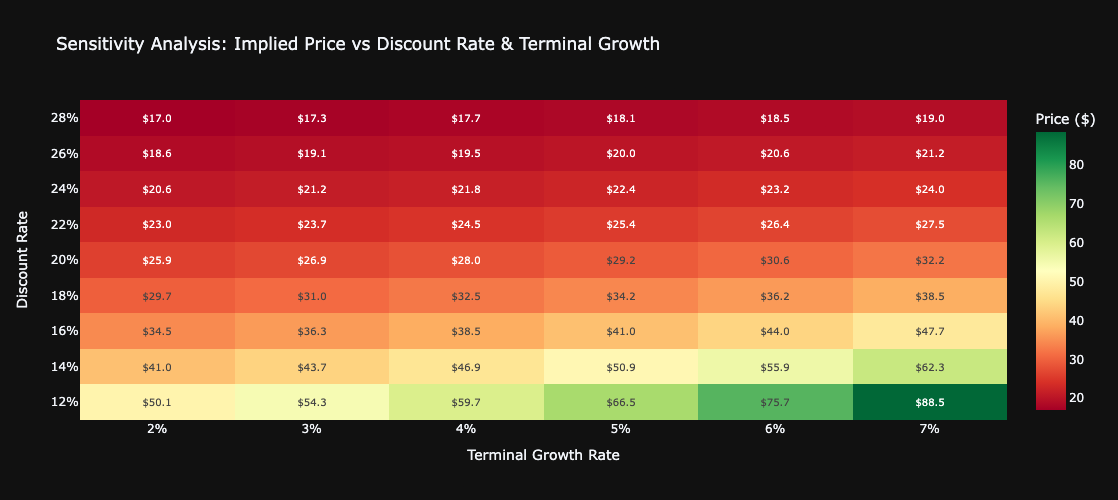

In [13]:
# Sensitivity: Discount Rate vs Terminal Growth
discount_rates = np.arange(0.12, 0.28, 0.02)
terminal_rates = np.arange(0.02, 0.08, 0.01)

sensitivity_matrix = np.zeros((len(discount_rates), len(terminal_rates)))

base_growth_rates = [0.30, 0.25, 0.20, 0.15, 0.10]
base_revenue = 900_000_000

for i, dr in enumerate(discount_rates):
    for j, tg in enumerate(terminal_rates):
        if tg < dr:  # Terminal growth must be less than discount rate
            result = dcf_model.run_dcf(
                base_revenue=base_revenue,
                growth_rates=base_growth_rates,
                discount_rate=dr,
                terminal_growth=tg,
                include_deflationary=True,
                include_fee_switch=True
            )
            sensitivity_matrix[i, j] = result['implied_price_circulating']
        else:
            sensitivity_matrix[i, j] = np.nan

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=sensitivity_matrix,
    x=[f"{r*100:.0f}%" for r in terminal_rates],
    y=[f"{r*100:.0f}%" for r in discount_rates],
    colorscale='RdYlGn',
    text=[[f"${v:.1f}" if not np.isnan(v) else "" for v in row] for row in sensitivity_matrix],
    texttemplate="%{text}",
    textfont={"size": 10},
    hoverongaps=False,
    colorbar_title="Price ($)"
))

fig.update_layout(
    title='Sensitivity Analysis: Implied Price vs Discount Rate & Terminal Growth',
    xaxis_title='Terminal Growth Rate',
    yaxis_title='Discount Rate',
    height=500,
    template='plotly_dark'
)

display(fig)

In [22]:
# Monte Carlo Simulation
from doctest import FAIL_FAST


def run_monte_carlo(n_simulations=10000):
    """
    Run Monte Carlo simulation with randomized inputs.
    """
    np.random.seed(42)
    
    results = []
    
    for _ in range(n_simulations):
        # Randomize inputs within reasonable ranges
        base_rev = np.random.triangular(600e6, 900e6, 1200e6)
        
        # Growth rates with declining trend
        y1 = np.random.triangular(0.10, 0.30, 0.60)
        y2 = np.random.triangular(0.05, 0.25, 0.50) * (y1 / 0.30)
        y3 = np.random.triangular(0.00, 0.20, 0.40) * (y2 / 0.25)
        y4 = np.random.triangular(-0.05, 0.15, 0.30) * (y3 / 0.20)
        y5 = np.random.triangular(-0.10, 0.10, 0.25)
        
        dr = np.random.triangular(0.12, 0.18, 0.25)
        tg = np.random.triangular(0.02, 0.04, 0.06)
        
        if tg >= dr:
            tg = dr - 0.05
        
        result = dcf_model.run_dcf(
            base_revenue=base_rev,
            growth_rates=[y1, y2, y3, y4, y5],
            discount_rate=dr,
            terminal_growth=tg,
            include_deflationary=True,
            include_fee_switch=True
        )
        
        results.append(result['implied_price_circulating'])
    
    return np.array(results)

print("Running Monte Carlo simulation (10,000 iterations)...")
mc_prices = run_monte_carlo()

# Statistics
mc_mean = np.mean(mc_prices)
mc_median = np.median(mc_prices)
mc_std = np.std(mc_prices)
mc_5th = np.percentile(mc_prices, 5)
mc_95th = np.percentile(mc_prices, 95)

# Create distribution plot
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=mc_prices,
    nbinsx=100,
    name='Price Distribution',
    marker_color='#00D4AA',
    opacity=0.7
))

# Add vertical lines for key stats
fig.add_vline(x=mc_mean, line_dash="solid", line_color="#00D4AA",
              annotation_text=f"Mean:${mc_mean:.2f}", annotation_position="top right")
fig.add_vline(x=mc_median, line_dash="dash", line_color="#FFD700",
              annotation_text=f"Median:${mc_median:.2f}", annotation_position="bottom right")
fig.add_vline(x=CORE_METRICS['current_price'], line_dash="dot", line_color="#FF6B6B",
              annotation_text=f"Current: ${CORE_METRICS['current_price']:.2f}", annotation_position="top left")

fig.update_layout(
    title='Monte Carlo Simulation: HYPE Price Distribution (10,000 iterations)',
    xaxis_title='Implied Price ($)',
    yaxis_title='Frequency',
    height=500,
    template='plotly_dark',
    showlegend=False
)

fig.show()

# Summary statistics
prob_above_current = (mc_prices > CORE_METRICS['current_price']).mean() * 100

mc_summary = f"""
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); 
            padding: 20px; border-radius: 10px;">
    <h3 style="color: #7B68EE;">🎲 Monte Carlo Results</h3>
    <table style="width: 100%; color: white;">
        <tr><td>Mean Price:</td><td style="text-align: right;"><b>${mc_mean:.2f}</b></td></tr>
        <tr><td>Median Price:</td><td style="text-align: right;">${mc_median:.2f}</td></tr>
        <tr><td>Std Deviation:</td><td style="text-align: right;">${mc_std:.2f}</td></tr>
        <tr><td>5th Percentile:</td><td style="text-align: right; color: #FF6B6B;">${mc_5th:.2f}</td></tr>
        <tr><td>95th Percentile:</td><td style="text-align: right; color: #00D4AA;">${mc_95th:.2f}</td></tr>
        <tr style="border-top: 1px solid #444;">
            <td><b>Probability Above Current:</b></td>
            <td style="text-align: right; color: {'#00D4AA' if prob_above_current > 50 else '#FF6B6B'};"><b>{prob_above_current:.1f}%</b></td>
        </tr>
    </table>
</div>
"""
display(HTML(mc_summary))

Running Monte Carlo simulation (10,000 iterations)...


Mean Price:,$36.87
Median Price:,$33.27
Std Deviation:,$15.94
5th Percentile:,$19.15
95th Percentile:,$66.55
Probability Above Current:,76.4%


## 7. Comparable Analysis

Cross-check DCF with market multiples.

In [23]:
# Comparable protocol data (as of Jan 2026)
COMPARABLES = pd.DataFrame([
    {'Protocol': 'HYPE (Hyperliquid)', 'Revenue_M': 845.6, 'MarketCap_B': 5.2, 'TVL_B': 4.48, 'Category': 'Perp DEX'},
    {'Protocol': 'Ethereum', 'Revenue_M': 524, 'MarketCap_B': 380, 'TVL_B': 50, 'Category': 'L1'},
    {'Protocol': 'Solana', 'Revenue_M': 1300, 'MarketCap_B': 95, 'TVL_B': 8, 'Category': 'L1'},
    {'Protocol': 'dYdX', 'Revenue_M': 50, 'MarketCap_B': 0.8, 'TVL_B': 0.3, 'Category': 'Perp DEX'},
    {'Protocol': 'GMX', 'Revenue_M': 100, 'MarketCap_B': 0.3, 'TVL_B': 0.5, 'Category': 'Perp DEX'},
    {'Protocol': 'Aave', 'Revenue_M': 150, 'MarketCap_B': 3.5, 'TVL_B': 12, 'Category': 'Lending'},
    {'Protocol': 'Uniswap', 'Revenue_M': 700, 'MarketCap_B': 6.5, 'TVL_B': 5, 'Category': 'Spot DEX'},
])

# Calculate multiples
COMPARABLES['P/S'] = COMPARABLES['MarketCap_B'] * 1000 / COMPARABLES['Revenue_M']
COMPARABLES['MC/TVL'] = COMPARABLES['MarketCap_B'] / COMPARABLES['TVL_B']

# Create visualization
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Price-to-Sales Ratio', 'Market Cap / TVL')
)

# Color HYPE differently
colors = ['#00D4AA' if p == 'HYPE (Hyperliquid)' else '#7B68EE' for p in COMPARABLES['Protocol']]

# P/S chart
fig.add_trace(
    go.Bar(
        x=COMPARABLES['Protocol'],
        y=COMPARABLES['P/S'],
        marker_color=colors,
        text=[f"{v:.1f}x" for v in COMPARABLES['P/S']],
        textposition='outside'
    ),
    row=1, col=1
)

# MC/TVL chart
fig.add_trace(
    go.Bar(
        x=COMPARABLES['Protocol'],
        y=COMPARABLES['MC/TVL'],
        marker_color=colors,
        text=[f"{v:.1f}x" for v in COMPARABLES['MC/TVL']],
        textposition='outside'
    ),
    row=1, col=2
)

fig.update_layout(
    height=450,
    showlegend=False,
    title_text="HYPE vs. Comparable Protocols - Valuation Multiples",
    template='plotly_dark'
)

fig.update_xaxes(tickangle=45)
fig.show()

# Implied valuations at peer multiples
hype_revenue = 845.6  # $M
perp_dex_avg_ps = COMPARABLES[COMPARABLES['Category'] == 'Perp DEX']['P/S'].mean()
all_avg_ps = COMPARABLES['P/S'].mean()

implied_at_perp_avg = hype_revenue * perp_dex_avg_ps / 1000  # $B
implied_at_market_avg = hype_revenue * all_avg_ps / 1000  # $B

comps_html = f"""
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); 
            padding: 20px; border-radius: 10px; margin-top: 20px;">
    <h3 style="color: #00D4AA;">Comparable Valuation Implications</h3>
    <table style="width: 100%; color: white;">
        <tr>
            <td>HYPE Current P/S:</td>
            <td style="text-align: right;"><b>{COMPARABLES[COMPARABLES['Protocol']=='HYPE (Hyperliquid)']['P/S'].values[0]:.1f}x</b></td>
        </tr>
        <tr>
            <td>Perp DEX Avg P/S:</td>
            <td style="text-align: right;">{perp_dex_avg_ps:.1f}x</td>
        </tr>
        <tr>
            <td>All Protocols Avg P/S:</td>
            <td style="text-align: right;">{all_avg_ps:.1f}x</td>
        </tr>
        <tr style="border-top: 1px solid #444;">
            <td>Implied MC @ Perp DEX Avg:</td>
            <td style="text-align: right;"><b>${implied_at_perp_avg:.1f}B</b></td>
        </tr>
        <tr>
            <td>Implied MC @ Market Avg:</td>
            <td style="text-align: right;"><b>${implied_at_market_avg:.1f}B</b></td>
        </tr>
    </table>
    <p style="color: #888; font-size: 12px; margin-top: 10px;">
        Note: HYPE trades at a premium to Perp DEX peers reflecting market dominance and L1 aspirations.
    </p>
</div>
"""
display(HTML(comps_html))

HYPE Current P/S:,6.1x
Perp DEX Avg P/S:,8.4x
All Protocols Avg P/S:,122.3x
Implied MC @ Perp DEX Avg:,$7.1B
Implied MC @ Market Avg:,$103.4B


## 8. Risk Factors & Investment Thesis

Key considerations for the valuation.

In [24]:
risk_html = """
<div style="background: linear-gradient(135deg, #2d1f3d 0%, #1a1a2e 100%); 
            padding: 25px; border-radius: 12px; margin: 20px 0;">
    <h2 style="color: #FFD700; margin-bottom: 20px;">⚠️ Risk Factors</h2>
    
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div style="background: rgba(255,107,107,0.1); padding: 15px; border-radius: 8px; border-left: 4px solid #FF6B6B;">
            <h4 style="color: #FF6B6B;">High Risk</h4>
            <ul style="color: #ddd; margin: 0;">
                <li><b>Competition:</b> dYdX v4, GMX v2, CEX improvements</li>
                <li><b>Regulatory:</b> Derivatives regulation in US/EU</li>
                <li><b>Smart Contract:</b> Novel HyperBFT consensus</li>
                <li><b>Token Unlocks:</b> 63% of supply still locked</li>
            </ul>
        </div>
        
        <div style="background: rgba(255,215,0,0.1); padding: 15px; border-radius: 8px; border-left: 4px solid #FFD700;">
            <h4 style="color: #FFD700;">Medium Risk</h4>
            <ul style="color: #ddd; margin: 0;">
                <li><b>Market Dependency:</b> Revenue tied to crypto cycles</li>
                <li><b>Concentration:</b> Heavy reliance on BTC/ETH perps</li>
                <li><b>HyperEVM Adoption:</b> Ecosystem still nascent</li>
            </ul>
        </div>
    </div>
    
    <h2 style="color: #00D4AA; margin: 30px 0 20px 0;">Investment Thesis</h2>
    
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
        <div style="background: rgba(0,212,170,0.1); padding: 15px; border-radius: 8px; border-left: 4px solid #00D4AA;">
            <h4 style="color: #00D4AA;">Bull Case</h4>
            <ul style="color: #ddd; margin: 0;">
                <li><b>Market Dominance:</b> 70%+ perp market share</li>
                <li><b>Revenue Machine:</b> $845M in 2025, growing</li>
                <li><b>HyperEVM:</b> Full DeFi ecosystem on fastest L1</li>
                <li><b>Fee Switch:</b> Potential for direct staking rewards</li>
                <li><b>Deflationary:</b> Active buyback + burn mechanics</li>
            </ul>
        </div>
        
        <div style="background: rgba(123,104,238,0.1); padding: 15px; border-radius: 8px; border-left: 4px solid #7B68EE;">
            <h4 style="color: #7B68EE;">Key Catalysts</h4>
            <ul style="color: #ddd; margin: 0;">
                <li><b>Spot Trading Growth:</b> $1B in incentives</li>
                <li><b>HyperEVM Apps:</b> Lending, derivatives, NFTs</li>
                <li><b>Institutional Adoption:</b> On-chain transparency</li>
                <li><b>Geographic Expansion:</b> Non-US markets</li>
                <li><b>Crypto Bull Market:</b> Volume correlation</li>
            </ul>
        </div>
    </div>
</div>
"""
display(HTML(risk_html))

## 9. Timeline Analysis & Price Trajectories

Year-by-year and decade-long price forecasts with realization timelines.

In [25]:
def calculate_timeline_projections(base_price, base_revenue, scenarios_config):
    """
    Calculate year-by-year price trajectories for each scenario.
    Extended to 10 years with long-term terminal projections.
    """
    results = {}
    
    for scenario_name, config in scenarios_config.items():
        # Extend growth rates to 10 years (decay toward terminal)
        base_growth = config['growth_rates']
        terminal_g = config['terminal_growth']
        
        # Years 6-10: linear decay from Y5 growth to terminal growth
        y5_growth = base_growth[-1]
        extended_growth = base_growth.copy()
        for i in range(5):
            decay_rate = y5_growth - (y5_growth - terminal_g) * (i + 1) / 5
            extended_growth.append(max(decay_rate, terminal_g))
        
        # Calculate year-by-year revenue
        revenues = [config['base_revenue']]
        for g in extended_growth[:-1]:
            revenues.append(revenues[-1] * (1 + g))
        
        # Calculate cumulative DCF value at each year-end
        discount_rate = config['discount_rate']
        profit_margin = 0.85
        
        yearly_prices = []
        years = list(range(2026, 2036))
        
        for year_idx in range(10):
            # Current year revenue (grows over time)
            current_rev = revenues[year_idx]
            
            # Future growth rates from this point
            future_growth = extended_growth[year_idx:] if year_idx < len(extended_growth) else [terminal_g] * 5
            
            # Project next 5 years of FCF from current revenue
            future_revenues = [current_rev]
            for g in future_growth[:5]:
                future_revenues.append(future_revenues[-1] * (1 + g))
            
            # Calculate FCF flows (years 1-5 ahead)
            future_fcf = [r * profit_margin for r in future_revenues[1:6]]
            
            # Discount future FCF
            discounted_fcf = [fcf / ((1 + discount_rate) ** (i + 1)) 
                             for i, fcf in enumerate(future_fcf)]
            
            # Terminal value (from year 5 ahead)
            terminal_fcf = future_fcf[-1] if future_fcf else current_rev * profit_margin
            terminal_val = (terminal_fcf * (1 + terminal_g)) / (discount_rate - terminal_g)
            discounted_terminal = terminal_val / ((1 + discount_rate) ** 6)
            
            # Enterprise value at this year (grows with revenue)
            ev = sum(discounted_fcf) + discounted_terminal
            
            # Apply premiums: ecosystem + revenue scale effects
            ecosystem_premium = 1.15
            # Revenue growth multiplier: as revenue grows, network effects increase value
            revenue_multiplier = 1 + ((current_rev / revenues[0]) - 1) * 0.3  # Up to 30% premium for scale
            ev *= ecosystem_premium * revenue_multiplier
            
            # Deflationary: supply reduces ~2% per year (compounds)
            cumulative_deflation = (1 - 0.02) ** year_idx
            
            # Supply at this year (unlocks minus burns)
            unlock_progress = min(0.37 + 0.126 * year_idx, 1.0)
            burned_supply = CORE_METRICS['total_supply'] * (1 - cumulative_deflation)
            effective_supply = CORE_METRICS['total_supply'] * unlock_progress - burned_supply
            effective_supply = max(effective_supply, CORE_METRICS['circulating_supply'] * 0.85)
            
            # Price: EV divided by effective supply (deflation increases per-token value)
            price = ev / (effective_supply * cumulative_deflation)
            yearly_prices.append(price)
        
        results[scenario_name] = {
            'years': years,
            'prices': yearly_prices,
            'revenues': revenues[:10],
            'growth_rates': extended_growth[:10]
        }
    
    return results

# Extended scenarios with 10-year horizon
EXTENDED_SCENARIOS = {
    'Bear': {
        'base_revenue': 700_000_000,
        'growth_rates': [0.05, 0.00, -0.05, 0.00, 0.05],
        'discount_rate': 0.22,
        'terminal_growth': 0.02
    },
    'Base': {
        'base_revenue': 900_000_000,
        'growth_rates': [0.30, 0.25, 0.20, 0.15, 0.10],
        'discount_rate': 0.18,
        'terminal_growth': 0.04
    },
    'Bull': {
        'base_revenue': 1_100_000_000,
        'growth_rates': [0.50, 0.40, 0.30, 0.25, 0.20],
        'discount_rate': 0.15,
        'terminal_growth': 0.05
    }
}

timeline_results = calculate_timeline_projections(
    CORE_METRICS['current_price'],
    CORE_METRICS['annual_revenue_2025'],
    EXTENDED_SCENARIOS
)

print("Timeline projections calculated.")

Timeline projections calculated.


In [26]:
# Visualize 10-year price trajectories
fig = go.Figure()

colors = {'Bear': '#FF6B6B', 'Base': '#FFD700', 'Bull': '#00D4AA'}
current_price = CORE_METRICS['current_price']

for scenario, data in timeline_results.items():
    fig.add_trace(go.Scatter(
        x=data['years'],
        y=data['prices'],
        mode='lines+markers',
        name=scenario,
        line=dict(color=colors[scenario], width=3),
        marker=dict(size=8)
    ))

# Add current price line
fig.add_hline(
    y=current_price,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Current: ${current_price:.2f}"
)

fig.update_layout(
    title='HYPE Price Trajectory: 10-Year Forecast (2026-2035)',
    xaxis_title='Year',
    yaxis_title='Price ($)',
    height=500,
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)

# Create timeline table
timeline_df = pd.DataFrame({
    'Year': timeline_results['Base']['years'],
    'Bear': [f"${p:.2f}" for p in timeline_results['Bear']['prices']],
    'Base': [f"${p:.2f}" for p in timeline_results['Base']['prices']],
    'Bull': [f"${p:.2f}" for p in timeline_results['Bull']['prices']],
})

display(HTML("<h3>Year-by-Year Price Targets</h3>"))
display(timeline_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

Year,Bear,Base,Bull
2026,$8.80,$30.87,$82.44
2027,$7.20,$29.89,$89.94
2028,$6.12,$29.85,$100.82
2029,$5.35,$30.09,$112.33
2030,$4.89,$30.23,$123.98
2031,$4.59,$30.02,$133.77
2032,$4.50,$30.91,$148.66
2033,$4.27,$30.86,$159.54
2034,$3.83,$29.55,$163.93
2035,$3.15,$26.61,$159.48


In [27]:
# Upside realization timeline
def calculate_upside_timeline(current_price, timeline_results):
    """
    Calculate when specific return multiples are reached.
    """
    milestones = [1.5, 2.0, 3.0, 5.0, 10.0]  # Return multiples
    milestone_prices = [current_price * m for m in milestones]
    
    results = []
    
    for mult, target_price in zip(milestones, milestone_prices):
        row = {'Multiple': f'{mult}x', 'Target': f'${target_price:.2f}'}
        
        for scenario in ['Bear', 'Base', 'Bull']:
            prices = timeline_results[scenario]['prices']
            years = timeline_results[scenario]['years']
            
            # Find first year where price exceeds target
            reached = None
            for yr, pr in zip(years, prices):
                if pr >= target_price:
                    reached = yr
                    break
            
            row[scenario] = str(reached) if reached else '>2035'
        
        results.append(row)
    
    return pd.DataFrame(results)

upside_timeline = calculate_upside_timeline(CORE_METRICS['current_price'], timeline_results)

display(HTML("<h3>Upside Realization Timeline</h3>"))
display(HTML(f"<p style='color: #888;'>Starting price: ${CORE_METRICS['current_price']:.2f}</p>"))
display(upside_timeline.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

Multiple,Target,Bear,Base,Bull
1.5x,$38.66,>2035,>2035,2026
2.0x,$51.55,>2035,>2035,2026
3.0x,$77.32,>2035,>2035,2026
5.0x,$128.87,>2035,>2035,2031
10.0x,$257.74,>2035,>2035,>2035


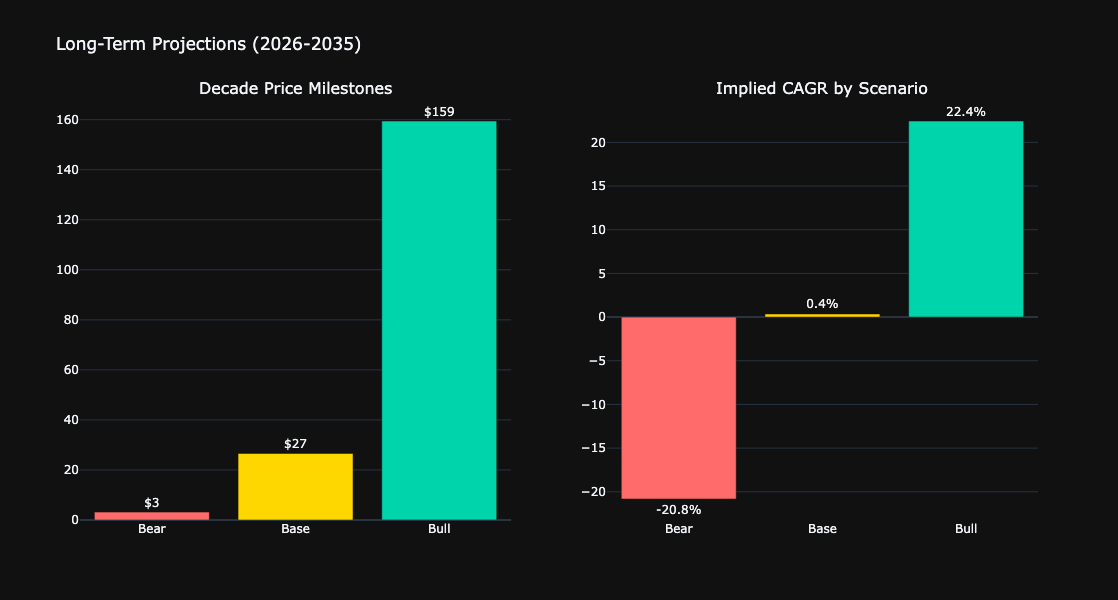

Scenario,2030,2035,2040,2050,CAGR 2026-2035
Bear,$4.89,$3.15,$3.48,$4.24,-20.8%
Base,$30.23,$26.61,$32.37,$47.92,0.4%
Bull,$123.98,$159.48,$203.54,$331.54,22.4%


In [28]:
# Long-term decade projections (2030, 2035, 2040)
def project_decades(base_2035_price, scenarios):
    """
    Extend projections to 2040 using terminal growth rates.
    """
    decade_projections = []
    
    for scenario in ['Bear', 'Base', 'Bull']:
        terminal_g = scenarios[scenario]['terminal_growth']
        price_2035 = timeline_results[scenario]['prices'][-1]
        
        # 2030 (from trajectory)
        price_2030 = timeline_results[scenario]['prices'][4]  # Index 4 = 2030
        
        # 2040: 5 more years of terminal growth
        price_2040 = price_2035 * ((1 + terminal_g) ** 5)
        
        # 2050: 15 more years of terminal growth from 2035
        price_2050 = price_2035 * ((1 + terminal_g) ** 15)
        
        decade_projections.append({
            'Scenario': scenario,
            '2030': f'${price_2030:.2f}',
            '2035': f'${price_2035:.2f}',
            '2040': f'${price_2040:.2f}',
            '2050': f'${price_2050:.2f}',
            'CAGR 2026-2035': f"{((price_2035/CORE_METRICS['current_price'])**(1/9) - 1)*100:.1f}%"
        })
    
    return pd.DataFrame(decade_projections)

decade_df = project_decades(None, EXTENDED_SCENARIOS)

# Visualization
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Decade Price Milestones', 'Implied CAGR by Scenario'),
    specs=[[{"type": "bar"}, {"type": "bar"}]]
)

scenarios_list = ['Bear', 'Base', 'Bull']
colors_list = ['#FF6B6B', '#FFD700', '#00D4AA']

# 2035 prices
prices_2035 = [timeline_results[s]['prices'][-1] for s in scenarios_list]
fig.add_trace(
    go.Bar(
        x=scenarios_list,
        y=prices_2035,
        marker_color=colors_list,
        text=[f"${p:.0f}" for p in prices_2035],
        textposition='outside',
        name='2035 Price'
    ),
    row=1, col=1
)

# CAGR
cagrs = [((timeline_results[s]['prices'][-1]/CORE_METRICS['current_price'])**(1/9) - 1)*100 
         for s in scenarios_list]
fig.add_trace(
    go.Bar(
        x=scenarios_list,
        y=cagrs,
        marker_color=colors_list,
        text=[f"{c:.1f}%" for c in cagrs],
        textposition='outside',
        name='9-Year CAGR'
    ),
    row=1, col=2
)

fig.update_layout(
    height=600,
    showlegend=False,
    title_text="Long-Term Projections (2026-2035)",
    template='plotly_dark'
)

fig.show()

display(HTML("<h3>Decade Projections</h3>"))
display(decade_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

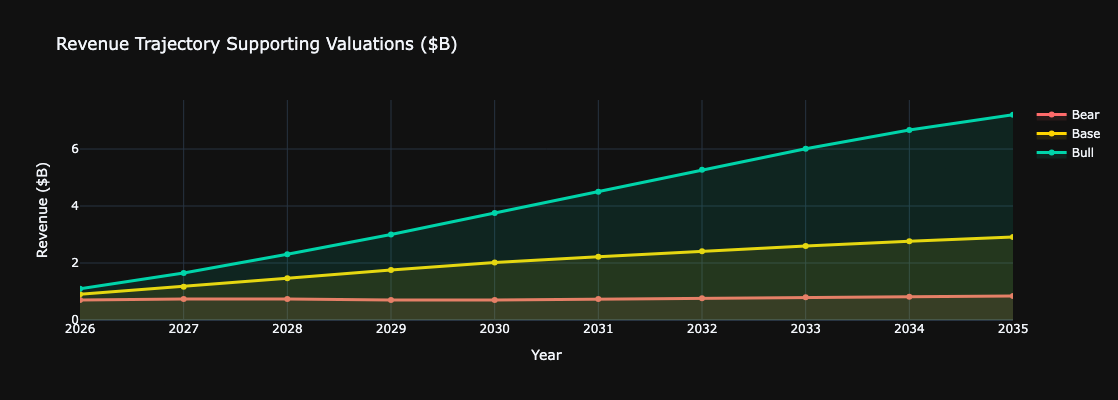

Horizon,Bear,Base,Bull
2026 (1 year),$8.80,$30.87,$82.44
2028 (3 years),$6.12,$29.85,$100.82
2030 (5 years),$4.89,$30.23,$123.98
2035 (10 years),$3.15,$26.61,$159.48


In [29]:
# Revenue trajectory supporting price projections
fig = go.Figure()

for scenario, data in timeline_results.items():
    fig.add_trace(go.Scatter(
        x=data['years'],
        y=[r/1e9 for r in data['revenues']],
        mode='lines+markers',
        name=scenario,
        line=dict(color=colors[scenario], width=3),
        fill='tozeroy',
        fillcolor=f"rgba{tuple(list(int(colors[scenario].lstrip('#')[i:i+2], 16) for i in (0, 2, 4)) + [0.1])}"
    ))

fig.update_layout(
    title='Revenue Trajectory Supporting Valuations ($B)',
    xaxis_title='Year',
    yaxis_title='Revenue ($B)',
    height=400,
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

# Summary table
summary_html = f"""
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); 
            padding: 25px; border-radius: 12px; margin-top: 20px;">
    <h3 style="color: #FFD700;">Timeline Summary</h3>
    
    <table style="width: 100%; color: white; border-collapse: collapse;">
        <tr style="border-bottom: 1px solid #444;">
            <th style="text-align: left; padding: 10px;">Horizon</th>
            <th style="text-align: center; padding: 10px;">Bear</th>
            <th style="text-align: center; padding: 10px;">Base</th>
            <th style="text-align: center; padding: 10px;">Bull</th>
        </tr>
        <tr>
            <td style="padding: 10px;"><b>2026 (1 year)</b></td>
            <td style="text-align: center; color: #FF6B6B;">${timeline_results['Bear']['prices'][0]:.2f}</td>
            <td style="text-align: center; color: #FFD700;">${timeline_results['Base']['prices'][0]:.2f}</td>
            <td style="text-align: center; color: #00D4AA;">${timeline_results['Bull']['prices'][0]:.2f}</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><b>2028 (3 years)</b></td>
            <td style="text-align: center; color: #FF6B6B;">${timeline_results['Bear']['prices'][2]:.2f}</td>
            <td style="text-align: center; color: #FFD700;">${timeline_results['Base']['prices'][2]:.2f}</td>
            <td style="text-align: center; color: #00D4AA;">${timeline_results['Bull']['prices'][2]:.2f}</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><b>2030 (5 years)</b></td>
            <td style="text-align: center; color: #FF6B6B;">${timeline_results['Bear']['prices'][4]:.2f}</td>
            <td style="text-align: center; color: #FFD700;">${timeline_results['Base']['prices'][4]:.2f}</td>
            <td style="text-align: center; color: #00D4AA;">${timeline_results['Bull']['prices'][4]:.2f}</td>
        </tr>
        <tr style="border-top: 1px solid #444;">
            <td style="padding: 10px;"><b>2035 (10 years)</b></td>
            <td style="text-align: center; color: #FF6B6B;"><b>${timeline_results['Bear']['prices'][9]:.2f}</b></td>
            <td style="text-align: center; color: #FFD700;"><b>${timeline_results['Base']['prices'][9]:.2f}</b></td>
            <td style="text-align: center; color: #00D4AA;"><b>${timeline_results['Bull']['prices'][9]:.2f}</b></td>
        </tr>
    </table>
    
    <p style="color: #888; font-size: 12px; margin-top: 15px;">
        Projections account for: revenue growth decay, token unlock schedule (37% -> 100% by 2031), 
        deflationary burns (~2%/yr), and ecosystem premium (15%).
    </p>
</div>
"""
display(HTML(summary_html))

## 10. Final Summary & Price Targets

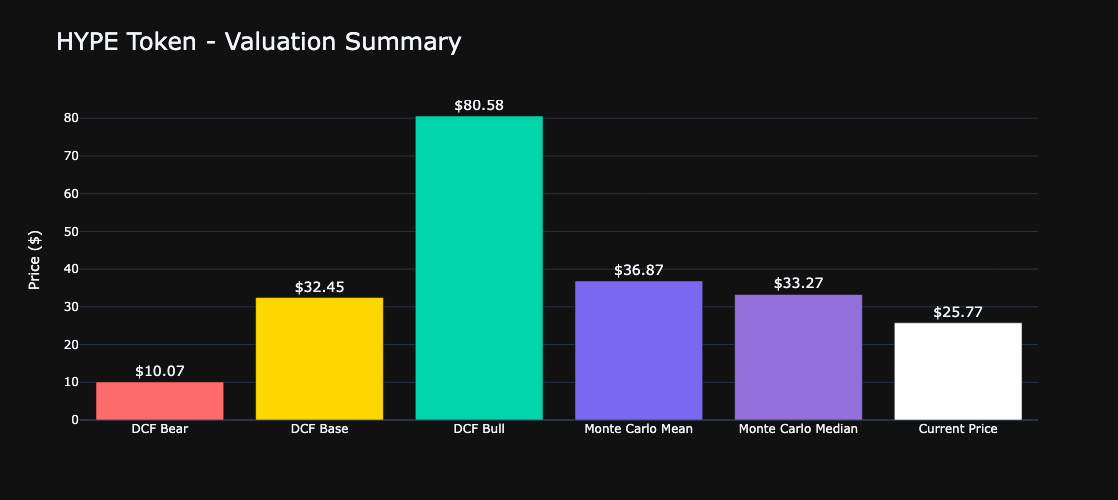

Bear Case (20%):,$10.07
Base Case (50%):,$32.45
Bull Case (30%):,$80.58


In [30]:
# Final summary with all methodologies
final_summary = {
    'DCF Bear': scenario_results['Bear']['implied_price_circulating'],
    'DCF Base': scenario_results['Base']['implied_price_circulating'],
    'DCF Bull': scenario_results['Bull']['implied_price_circulating'],
    'Monte Carlo Mean': mc_mean,
    'Monte Carlo Median': mc_median,
    'Current Price': CORE_METRICS['current_price']
}

# Create final visualization
fig = go.Figure()

# Add price targets
labels = list(final_summary.keys())
values = list(final_summary.values())
colors = ['#FF6B6B', '#FFD700', '#00D4AA', '#7B68EE', '#9370DB', '#FFFFFF']

fig.add_trace(go.Bar(
    x=labels,
    y=values,
    marker_color=colors,
    text=[f"${v:.2f}" for v in values],
    textposition='outside',
    textfont=dict(size=14)
))

fig.update_layout(
    title=dict(
        text='HYPE Token - Valuation Summary',
        font=dict(size=24)
    ),
    yaxis_title='Price ($)',
    height=500,
    template='plotly_dark',
    showlegend=False
)

fig.show()

# Final investment summary
weighted_price = (0.2 * final_summary['DCF Bear'] + 
                  0.5 * final_summary['DCF Base'] + 
                  0.3 * final_summary['DCF Bull'])

upside = (weighted_price / CORE_METRICS['current_price'] - 1) * 100

final_html = f"""
<div style="background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); 
            padding: 30px; border-radius: 15px; margin-top: 30px; text-align: center;">
    <h1 style="color: #FFD700; margin-bottom: 10px;">HYPE Token Valuation</h1>
    <p style="color: #888; font-size: 14px;">Based on DCF, Monte Carlo, and Comparable Analysis</p>
    
    <div style="display: flex; justify-content: space-around; margin: 30px 0;">
        <div>
            <p style="color: #888; margin-bottom: 5px;">Current Price</p>
            <h2 style="color: #FFFFFF; margin: 0;">${CORE_METRICS['current_price']:.2f}</h2>
        </div>
        <div>
            <p style="color: #888; margin-bottom: 5px;">Weighted Target</p>
            <h2 style="color: #00D4AA; margin: 0;">${weighted_price:.2f}</h2>
        </div>
        <div>
            <p style="color: #888; margin-bottom: 5px;">Upside</p>
            <h2 style="color: {'#00D4AA' if upside > 0 else '#FF6B6B'}; margin: 0;">{upside:+.0f}%</h2>
        </div>
    </div>
    
    <div style="background: rgba(255,255,255,0.05); padding: 20px; border-radius: 10px; margin-top: 20px;">
        <h3 style="color: #7B68EE;">Price Target Ranges</h3>
        <table style="width: 100%; color: white; max-width: 500px; margin: 0 auto;">
            <tr><td>Bear Case (20%):</td><td style="text-align: right; color: #FF6B6B;"><b>${final_summary['DCF Bear']:.2f}</b></td></tr>
            <tr><td>Base Case (50%):</td><td style="text-align: right; color: #FFD700;"><b>${final_summary['DCF Base']:.2f}</b></td></tr>
            <tr><td>Bull Case (30%):</td><td style="text-align: right; color: #00D4AA;"><b>${final_summary['DCF Bull']:.2f}</b></td></tr>
        </table>
    </div>
    
    <p style="color: #666; font-size: 11px; margin-top: 25px;">
        ⚠️ This is not financial advice. DYOR ;)
    </p>
</div>
"""
display(HTML(final_html))

---

## Data Sources & References

- [ASXN Hyperliquid Dashboard](https://hyperscreener.asxn.xyz/home) - Real-time trading metrics
- [Hyperliquid Stats](https://stats.hyperliquid.xyz/) - Official protocol statistics
- [Token Terminal](https://tokenterminal.com/explorer/projects/hyperliquid) - Revenue & financial data
- [DeFiLlama](https://defillama.com/protocol/hyperliquid) - TVL & protocol metrics
- [Tokenomist](https://tokenomist.ai/hyperliquid) - Token unlock schedules

---

*Model created: January 26th 2026*  